In [268]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [269]:
# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

In [270]:
# First 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [271]:
# Dataset shape
print("\nShape (rows, columns):")
print(df.shape)


Shape (rows, columns):
(1000, 8)


In [272]:
# Column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [273]:
# Basic information
print("\nInfo:")
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [274]:
# Missing values check
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [275]:
# Create new feature: average score
df["average score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

In [276]:
# Convert categorical values into numeric

df["gender"] = df["gender"].map({"male": 0, "female": 1})

df["test preparation course"] = df["test preparation course"].map({
    "none": 0,
    "completed": 1
})

In [277]:
# Graph style set (makes graphs clean and readable)
sns.set_style("whitegrid")

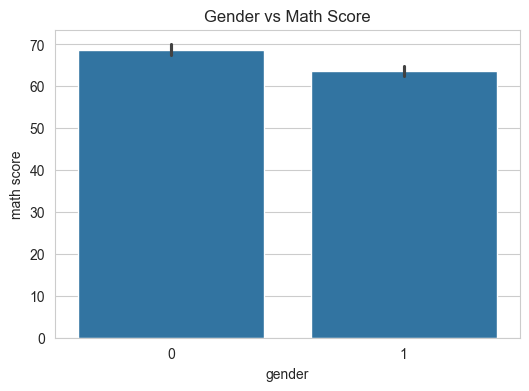

In [278]:
# Graph size set
plt.figure(figsize=(6,4))

# Gender vs Math score comparison
sns.barplot(x="gender", y="math score", data=df)

# Title for clarity
plt.title("Gender vs Math Score")

# Show graph
plt.show()

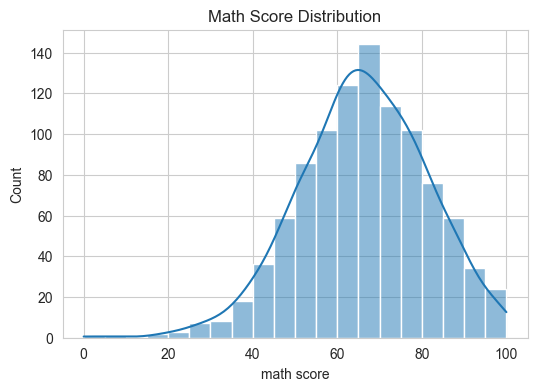

In [279]:
plt.figure(figsize=(6,4))

# Histogram + KDE (distribution curve)
sns.histplot(df["math score"], bins=20, kde=True)

plt.title("Math Score Distribution")
plt.show()

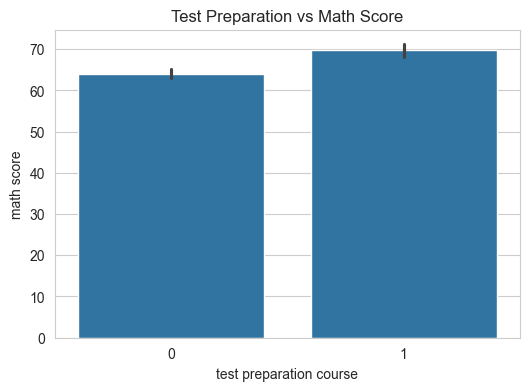

In [280]:
plt.figure(figsize=(6,4))

# Test prep vs performance
sns.barplot(x="test preparation course", y="math score", data=df)

plt.title("Test Preparation vs Math Score")

plt.show()

In [281]:
# Input features
X = df[[
    "gender",
    "math score",
    "reading score",
    "writing score",
    "test preparation course"
]]

# Target variable
y = df["average score"]

In [282]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [283]:
# Linear Regression is used for predicting continuous values
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [284]:
# Create Linear Regression model object
lr_model = LinearRegression()

In [285]:
# Train model using training data
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [286]:
# Predict output on test data
lr_pred = lr_model.predict(X_test)

In [287]:
from sklearn.metrics import r2_score, mean_absolute_error

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

MAE: 1.13509202037676e-14
R2 Score: 1.0


In [288]:
# Decision Tree is a non-linear regression model
# It splits data into multiple decision rules

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [289]:
# Create Decision Tree model object
dt_model = DecisionTreeRegressor(random_state=42)

In [290]:
# Train Decision Tree model
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [291]:
# Predict on test data
dt_pred = dt_model.predict(X_test)

In [292]:
# Evaluate model performance

print("Decision Tree Results:")
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("R2 Score:", r2_score(y_test, dt_pred))

Decision Tree Results:
MAE: 0.98
R2 Score: 0.9893951124530147


In [293]:
# Random Forest is an ensemble learning model
# It combines multiple Decision Trees for better accuracy

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [294]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

In [295]:
# Train Random Forest model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [296]:
# Predict using test data
rf_pred = rf_model.predict(X_test)

In [297]:
# Evaluate model performance

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results:
MAE: 0.4684333333333312
R2 Score: 0.9947388447960195


In [298]:
# KNN predicts value based on nearest data points

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [299]:
# Scaling is required because KNN uses distance

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [300]:
# Create KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)

In [301]:
# Train KNN model using scaled data
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [302]:
# Predict using test data
knn_pred = knn_model.predict(X_test_scaled)

In [303]:
# Evaluate KNN model

print("KNN Results:")
print("MAE:", mean_absolute_error(y_test, knn_pred))
print("R2 Score:", r2_score(y_test, knn_pred))

KNN Results:
MAE: 0.6420000000000025
R2 Score: 0.9884803761117185


In [304]:
# Create classification target
# 1 = Pass, 0 = Fail

df["result"] = df["average score"].apply(lambda x: 1 if x >= 70 else 0)

In [305]:
# Input features
X_cls = df[[
    "gender",
    "math score",
    "reading score",
    "writing score",
    "test preparation course"
]]

# Target variable (classification)
y_cls = df["result"]

In [306]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42
)

In [307]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
log_model = LogisticRegression()

In [308]:
from sklearn.preprocessing import StandardScaler

scaler_cls = StandardScaler()

X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

In [309]:
# Train
log_model.fit(X_train_cls_scaled, y_train_cls)

# Predict
log_pred = log_model.predict(X_test_cls_scaled)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test_cls, log_pred))

Logistic Regression Accuracy: 1.0


In [310]:
from sklearn.naive_bayes import GaussianNB

# Create model
nb_model = GaussianNB()

# Train
nb_model.fit(X_train_cls, y_train_cls)

# Predict
nb_pred = nb_model.predict(X_test_cls)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test_cls, nb_pred))

Naive Bayes Accuracy: 0.97


In [311]:
from sklearn.cluster import KMeans

In [312]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [313]:
# KMeans works best on numeric performance data only
X_unsup = df[[
    "math score",
    "reading score",
    "writing score"
]]

In [314]:
X_scaled = scaler.fit_transform(X_unsup)

In [315]:
# Create KMeans model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model
kmeans.fit(X_scaled)

# Cluster labels
clusters = kmeans.labels_

df["cluster"] = clusters

In [316]:
print("\n--- REGRESSION MODELS ---")
print("Linear Regression:", r2_score(y_test, lr_pred))
print("Decision Tree:", r2_score(y_test, dt_pred))
print("Random Forest:", r2_score(y_test, rf_pred))
print("KNN:", r2_score(y_test, knn_pred))

print("\n--- CLASSIFICATION MODELS ---")
print("Logistic Regression:", accuracy_score(y_test_cls, log_pred))
print("Naive Bayes:", accuracy_score(y_test_cls, nb_pred))


--- REGRESSION MODELS ---
Linear Regression: 1.0
Decision Tree: 0.9893951124530147
Random Forest: 0.9947388447960195
KNN: 0.9884803761117185

--- CLASSIFICATION MODELS ---
Logistic Regression: 1.0
Naive Bayes: 0.97


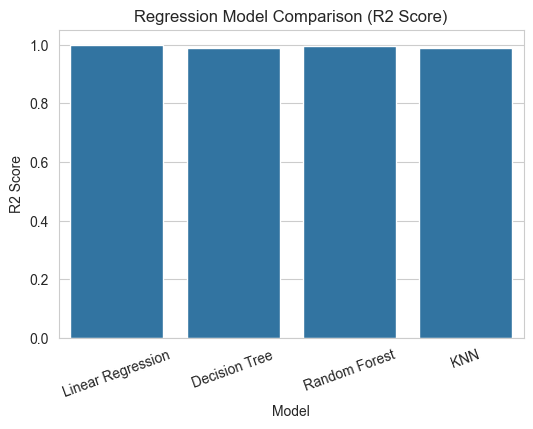

In [317]:
# Store regression results
regression_results = {
    "Linear Regression": r2_score(y_test, lr_pred),
    "Decision Tree": r2_score(y_test, dt_pred),
    "Random Forest": r2_score(y_test, rf_pred),
    "KNN": r2_score(y_test, knn_pred)
}

# Convert to DataFrame
reg_df = pd.DataFrame(list(regression_results.items()), columns=["Model", "R2 Score"])

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="R2 Score", data=reg_df)

plt.title("Regression Model Comparison (R2 Score)")
plt.xticks(rotation=20)
plt.show()

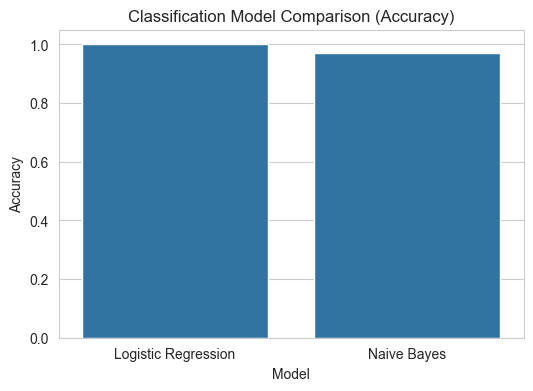

In [318]:
# Store classification results
classification_results = {
    "Logistic Regression": accuracy_score(y_test_cls, log_pred),
    "Naive Bayes": accuracy_score(y_test_cls, nb_pred)
}

# Convert to DataFrame
cls_df = pd.DataFrame(list(classification_results.items()), columns=["Model", "Accuracy"])

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=cls_df)

plt.title("Classification Model Comparison (Accuracy)")
plt.show()

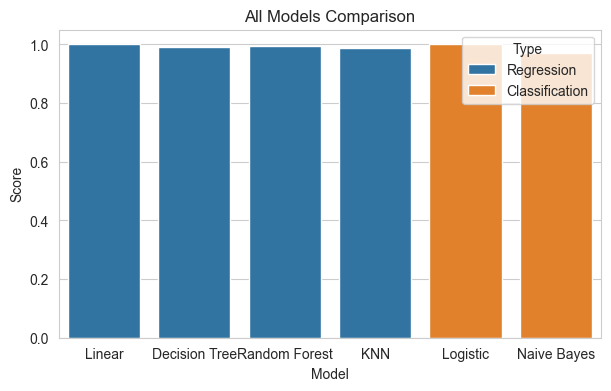

In [319]:
# Combine both
combined_df = pd.DataFrame({
    "Model": ["Linear", "Decision Tree", "Random Forest", "KNN", "Logistic", "Naive Bayes"],
    "Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, knn_pred),
        accuracy_score(y_test_cls, log_pred),
        accuracy_score(y_test_cls, nb_pred)
    ],
    "Type": ["Regression", "Regression", "Regression", "Regression", "Classification", "Classification"]
})

# Plot
plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="Score", hue="Type", data=combined_df)

plt.title("All Models Comparison")
plt.show()

In [320]:
best_reg_model = max(regression_results, key=regression_results.get)
best_cls_model = max(classification_results, key=classification_results.get)

print("Best Regression Model:", best_reg_model)
print("Best Classification Model:", best_cls_model)

Best Regression Model: Linear Regression
Best Classification Model: Logistic Regression


In [321]:
import pickle

# Save Linear Regression
pickle.dump(lr_model, open("lr_model.pkl", "wb"))

# Save Logistic Regression
pickle.dump(log_model, open("log_model.pkl", "wb"))

# Save scaler for classification
pickle.dump(scaler_cls, open("scaler.pkl", "wb"))